Lab 5 | House price prediction using Linear Regression-SingleVariable

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
dataset_bunch = fetch_california_housing(as_frame = True)
dataset = dataset_bunch.frame

In [4]:
dataset = dataset[['AveRooms', 'MedHouseVal']].copy()
dataset['AveRooms'] = (dataset['AveRooms'] * 1500).astype(int)
dataset['MedHouseVal'] = (dataset['MedHouseVal'] * 50000).astype(int)
dataset.columns = ['area', 'price']
dataset = dataset.iloc[:1460, :]

In [5]:
print(dataset.shape)
print(dataset.head(5))

(1460, 2)
    area   price
0  10476  226300
1   9357  179250
2  12432  176050
3   8726  170650
4   9422  171100


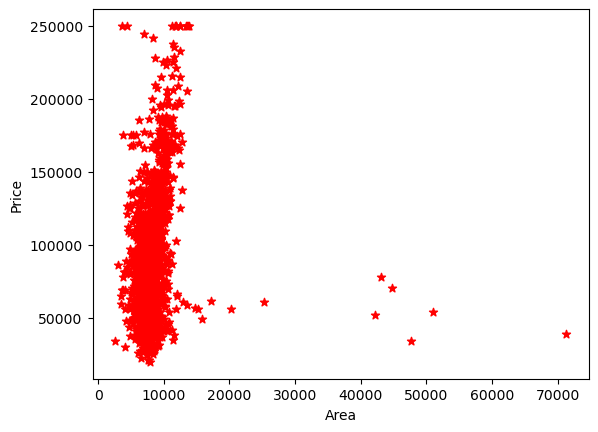

In [6]:
plt.xlabel('Area')
plt.ylabel('Price')
plt.scatter(dataset.area,dataset.price,color='red',marker='*')

In [8]:
X = dataset.drop('price',axis='columns')
X.head()

,area
0,10476
1,9357
2,12432
3,8726
4,9422


In [9]:
Y = dataset.price
Y.head()

0    226300
1    179250
2    176050
3    170650
4    171100
Name: price, dtype: int64

In [10]:
model = LinearRegression()
model.fit(X,Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
x=50000
LandAreainSqFt = pd.DataFrame([[x]], columns=['area'])
PredictedmodelResult = model.predict(LandAreainSqFt)

print(f"Predicted Price: ${PredictedmodelResult[0]:,.2f}")

Predicted Price: $179,438.10


In [13]:
m=model.coef_
print(m)

[2.0820264]


In [14]:
b=model.intercept_
print(b)

75336.77903061641


In [15]:
y = m*x + b
print("The Price of {0} Square feet Land is: {1}".format(x,y[0]))

The Price of 50000 Square feet Land is: 179438.09922533343
